In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


In [3]:
dados_vendas = {
    'mes': ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'],
    'vendas': [2000, 2200, 2300, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300]
}
df_vendas = pd.DataFrame.from_dict(dados_vendas)


### Preparação dos dados

In [4]:
df_vendas['mes_num'] = range(1, 13)

X = df_vendas[['mes_num']]
y = df_vendas['vendas']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)

### Treinamento do modelo

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Avaliando o modelo

In [6]:
# y_pred = model.predict(X_test)

# train_r2score = model.score(X_train, y_train)
# test_r2score = model.score(X_test, y_test)
# print(f"Resultado do R2 Score para o conjunto de TREINO: {train_r2score}")
# print(f"Resultado do R2 Score para o conjunto de TESTE: {test_r2score}")

y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

train_r2score = r2_score(y_train, y_train_pred)
test_r2score = r2_score(y_test, y_test_pred)
print(f"Resultado do R2 Score para o conjunto de TREINO: {train_r2score}")
print(f"Resultado do R2 Score para o conjunto de TESTE: {test_r2score}")

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
print(f"Resultado do MAE para o conjunto de TREINO: {train_mae}")
print(f"Resultado do MAE para o conjunto de TESTE: {test_mae}")

Resultado do R2 Score para o conjunto de TREINO: 0.9899261603375528
Resultado do R2 Score para o conjunto de TESTE: 0.966688988095238
Resultado do MAE para o conjunto de TREINO: 33.70370370370367
Resultado do MAE para o conjunto de TESTE: 35.00000000000015


### Predição das vendas para Dezembro

In [7]:
feature_to_pred = pd.DataFrame.from_dict({ 'mes_num': [12] })
december_pred = model.predict(feature_to_pred)
print(f"A previsão das vendas para dezembro é de {december_pred[0]} com margem de erro esperado até 36.7")

A previsão das vendas para dezembro é de 3337.5 com margem de erro esperado até 36.7


### Histograma

array([[<Axes: title={'center': 'vendas'}>,
        <Axes: title={'center': 'mes_num'}>]], dtype=object)

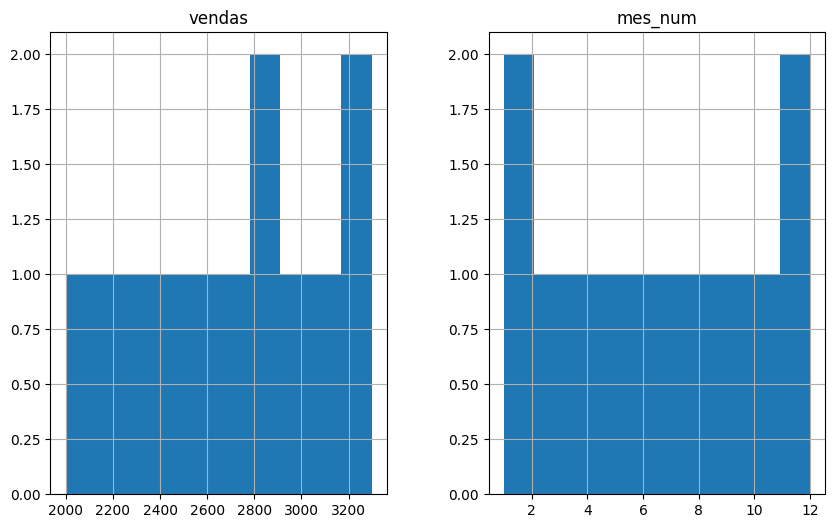

In [15]:
df_vendas.hist(figsize=[10,6])

### Scatter

<Figure size 1000x600 with 0 Axes>

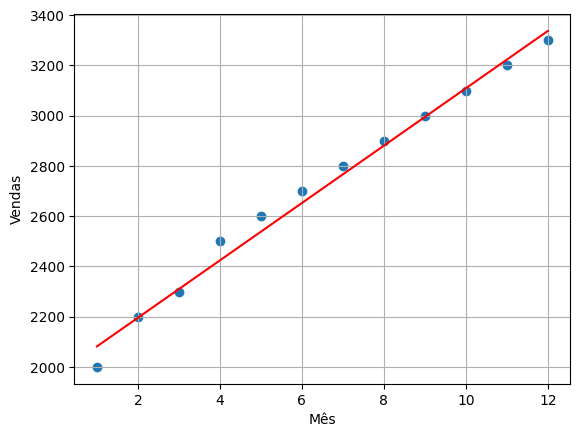

<Figure size 1000x600 with 0 Axes>

In [24]:
plt.scatter(X, y)
pred = model.predict(X)
plt.plot(X, pred, color='red')
plt.xlabel('Mês')
plt.ylabel('Vendas')
plt.grid(True)
plt.figure(figsize=[10,6])